In [1]:
import os
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import itertools

In [2]:
UEA_MTSC30 = ['EthanolConcentration',
              'FaceDetection',
              'Handwriting',
              'Heartbeat',
              'JapaneseVowels',
              'PEMS-SF',
              'SelfRegulationSCP1',
              'SelfRegulationSCP2',
              'SpokenArabicDigits',
              'UWaveGestureLibrary',
              'ArticularyWordRecognition',
              'AtrialFibrillation',
              'BasicMotions',
              'CharacterTrajectories',
              'Cricket',
              'DuckDuckGeese',
              'EigenWorms',
              'Epilepsy',
              'ERing',
              'FingerMovements',
              'HandMovementDirection',
              'InsectWingbeat',
              'Libras',
              'LSST',
              'MotorImagery',
              'NATOPS',
              'PenDigits',
              'PhonemeSpectra',
              'RacketSports',
              'StandWalkJump']

In [3]:
result_df_all = pd.read_csv('uea_interpgn.csv')
display(result_df_all.head())
print(result_df_all.columns)

,model,dnn_type,dataset,lambda_reg,lambda_div,epsilon,num_shapelet,gating_value,pos_weight,beta_schedule,...,shapelet_score,w_sum_10,w_mean_10,w_sum_5,w_mean_5,w_sum_1,w_mean_1,w_max,w_gini_clip,w_gini_abs
0,InterpGN,FCN,ArticularyWordRecognition,0.1,0.0,1.0,10,1.0,False,constant,...,0.036802,4.0,0.000296,247.0,0.018296,5681.0,0.420815,1.128440,0.737425,0.511019
1,InterpGN,FCN,ArticularyWordRecognition,0.0,0.1,1.0,10,1.0,False,constant,...,0.038096,4.0,0.000296,250.0,0.018519,5813.0,0.430593,1.123696,0.731100,0.499491
2,InterpGN,FCN,ArticularyWordRecognition,0.1,0.1,1.0,10,1.0,False,constant,...,0.036971,3.0,0.000222,235.0,0.017407,5660.0,0.419259,1.119726,0.737060,0.510390
3,InterpGN,FCN,ArticularyWordRecognition,0.1,0.1,1.0,10,1.0,False,cosine,...,0.036871,3.0,0.000222,233.0,0.017259,5646.0,0.418222,1.117687,0.737405,0.510965
4,InterpGN,FCN,ArticularyWordRecognition,0.1,0.1,2.0,10,1.0,False,constant,...,0.028526,46.0,0.003407,968.0,0.071704,6530.0,0.483704,2.278483,0.809133,0.599456


Index(['model', 'dnn_type', 'dataset', 'lambda_reg', 'lambda_div', 'epsilon',
       'num_shapelet', 'gating_value', 'pos_weight', 'beta_schedule', 'lr',
       'train_epochs', 'seed', 'test_accuracy', 'epoch_stop', 'eta_mean',
       'eta_std', 'eta_count', 'shapelet_score', 'w_sum_10', 'w_mean_10',
       'w_sum_5', 'w_mean_5', 'w_sum_1', 'w_mean_1', 'w_max', 'w_gini_clip',
       'w_gini_abs'],
      dtype='object')


In [ ]:
# 35 combination * 5 seeds = 175

result_df_all[['dnn_type', 'lambda_reg', 'lambda_div', 'epsilon', 'num_shapelet', 'gating_value']].drop_duplicates()

,dnn_type,lambda_reg,lambda_div,epsilon,num_shapelet,gating_value
0,FCN,0.1,0.0,1.0,10,1.0
1,FCN,0.0,0.1,1.0,10,1.0
2,FCN,0.1,0.1,1.0,10,1.0
4,FCN,0.1,0.1,2.0,10,1.0
5,FCN,0.1,0.1,5.0,10,1.0
6,FCN,0.1,0.1,10.0,10,1.0
7,FCN,0.1,0.1,0.5,10,1.0
8,FCN,0.1,0.1,1.0,10,0.5
9,FCN,0.1,0.1,1.0,10,0.6
10,FCN,0.1,0.1,1.0,10,0.7


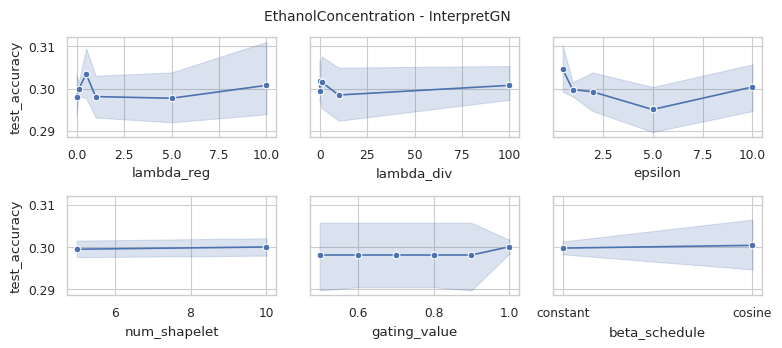

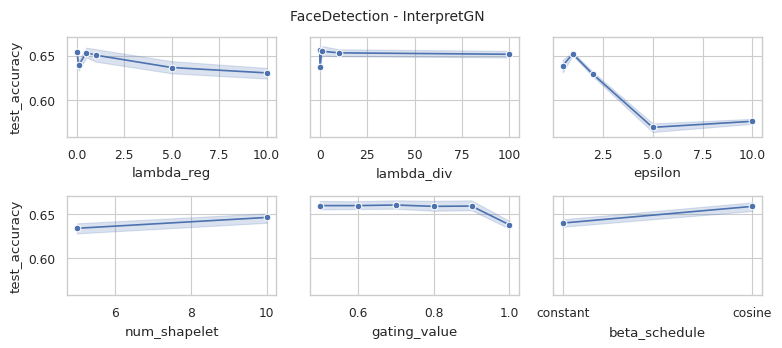

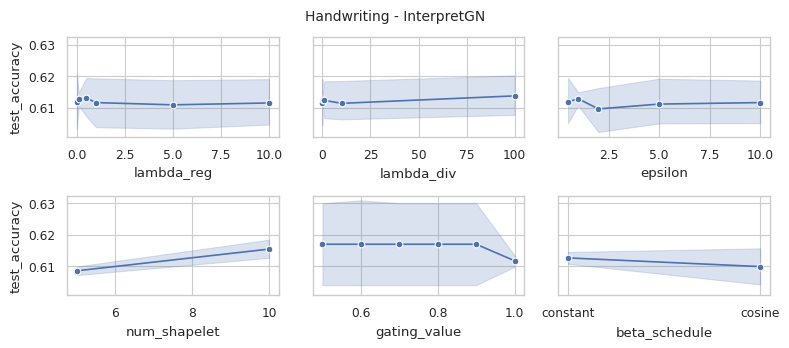

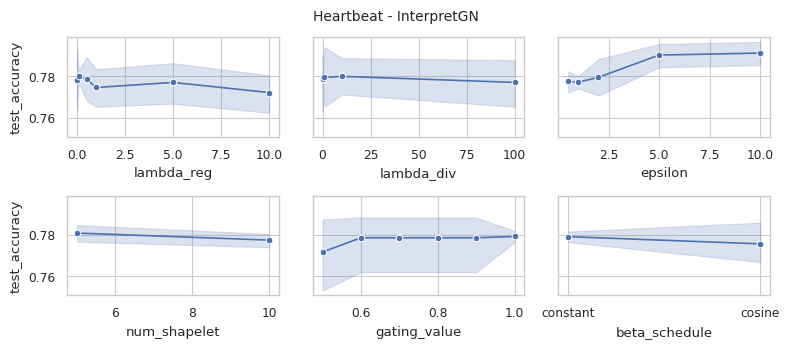

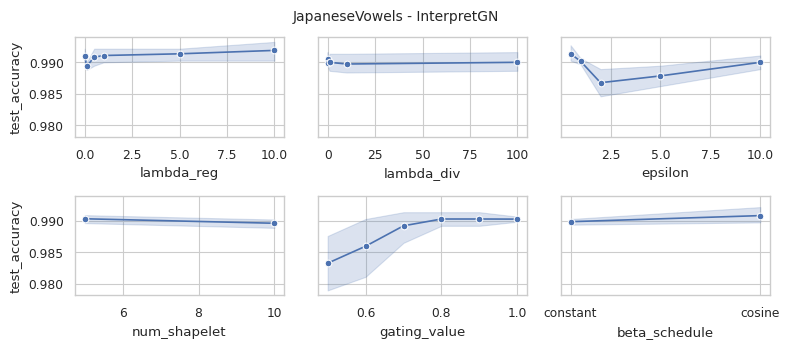

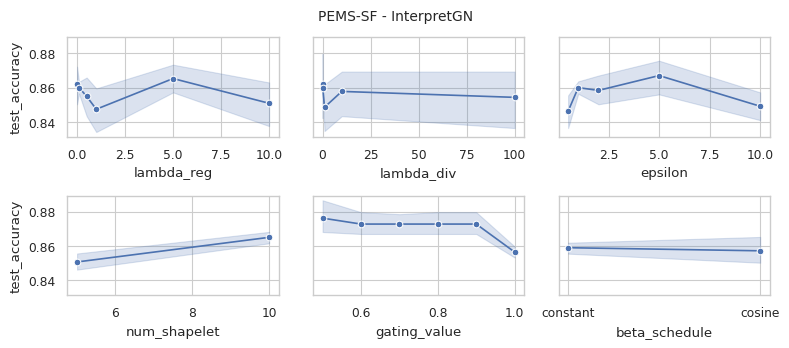

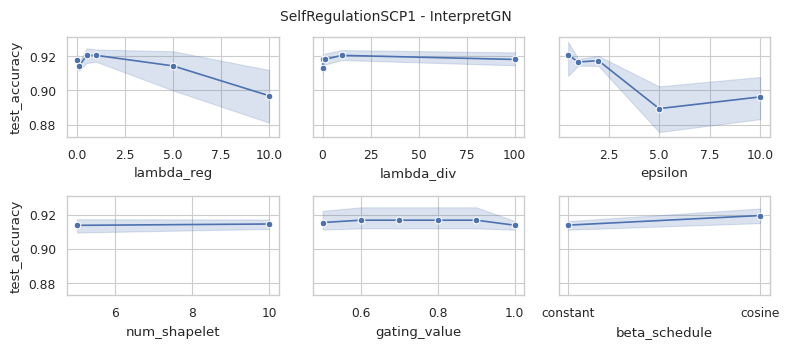

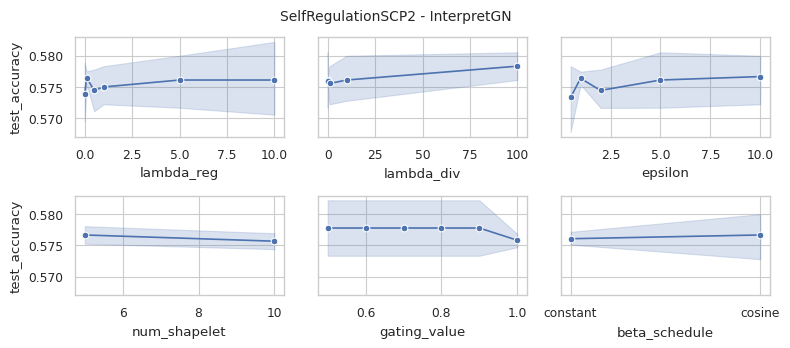

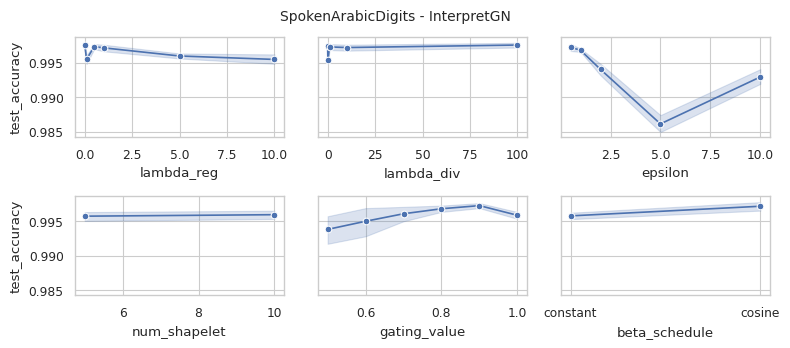

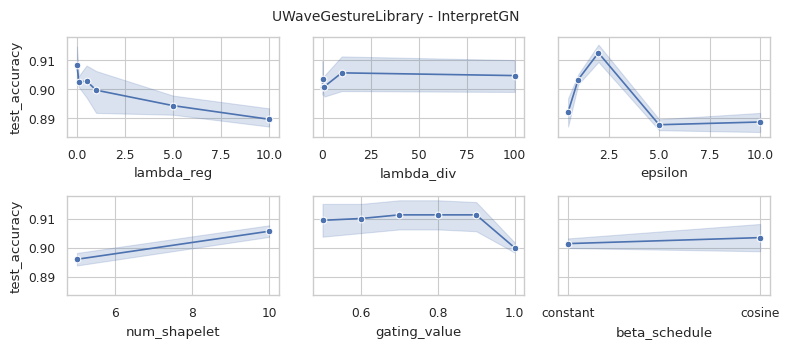

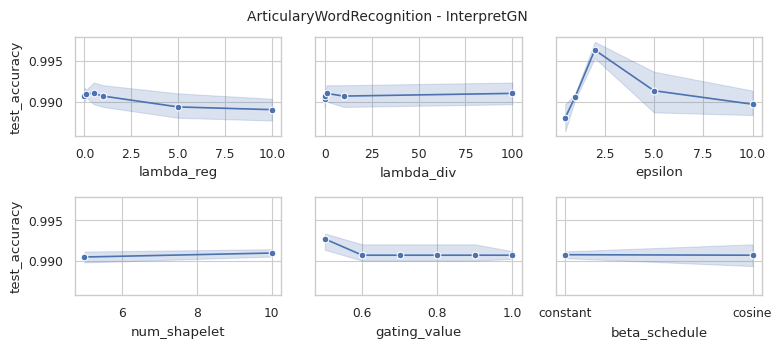

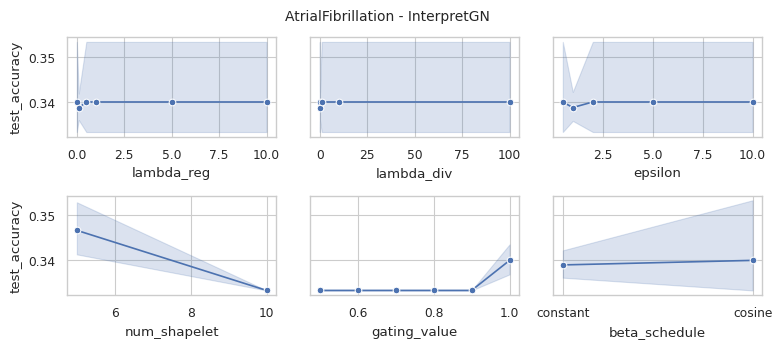

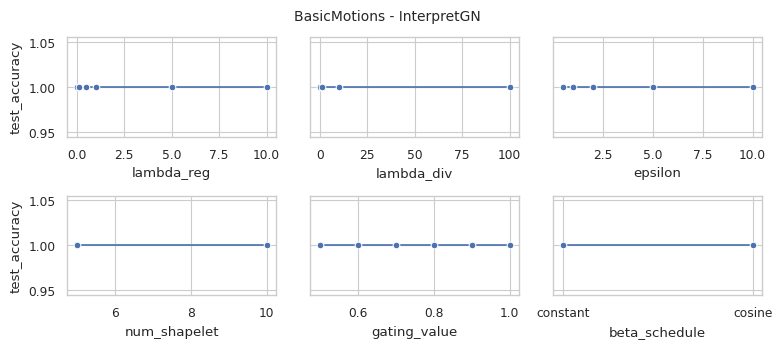

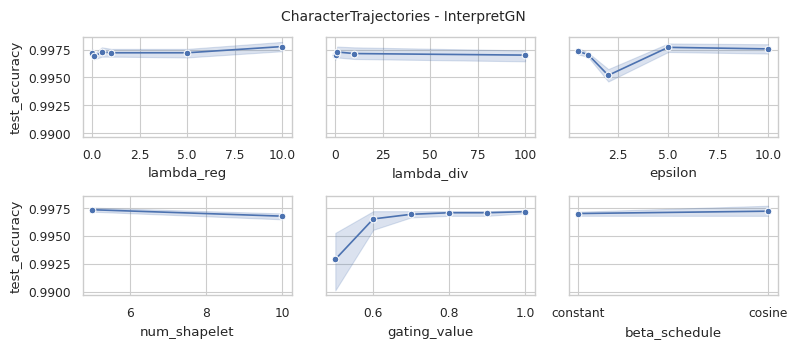

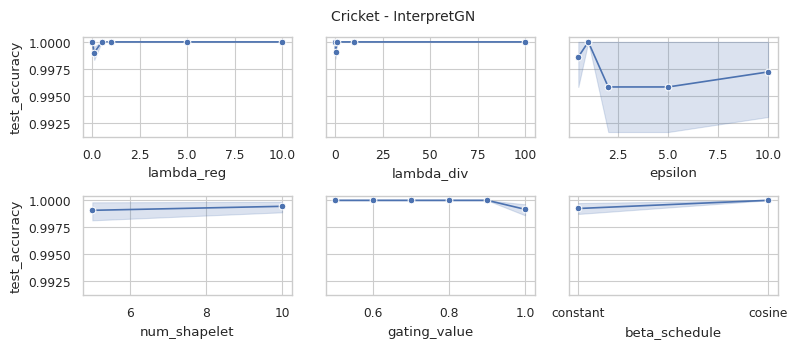

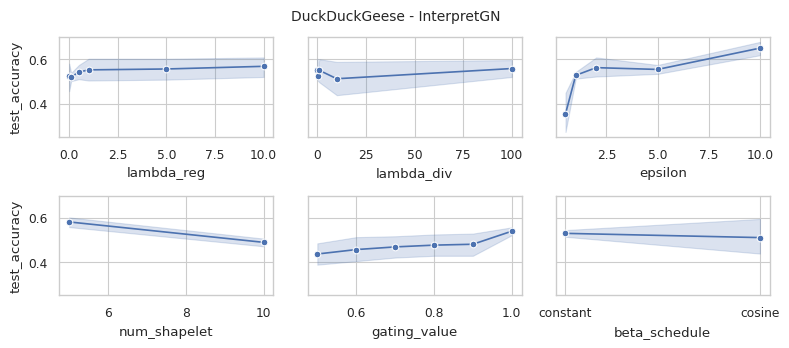

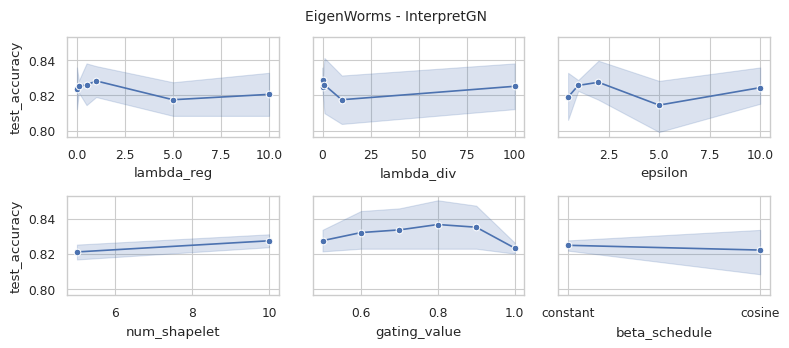

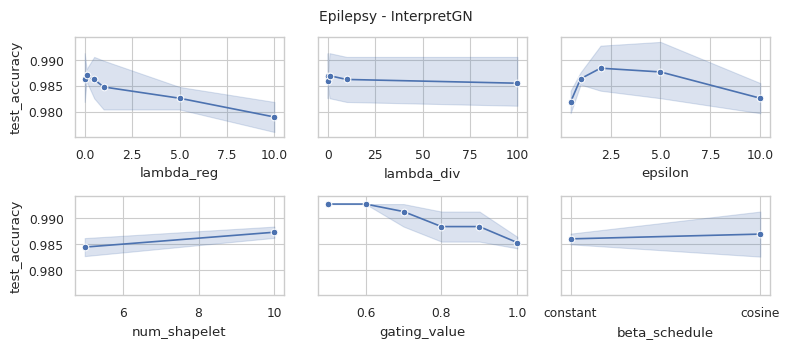

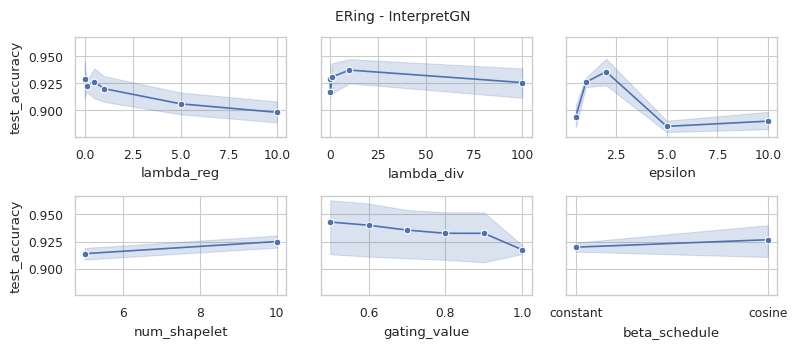

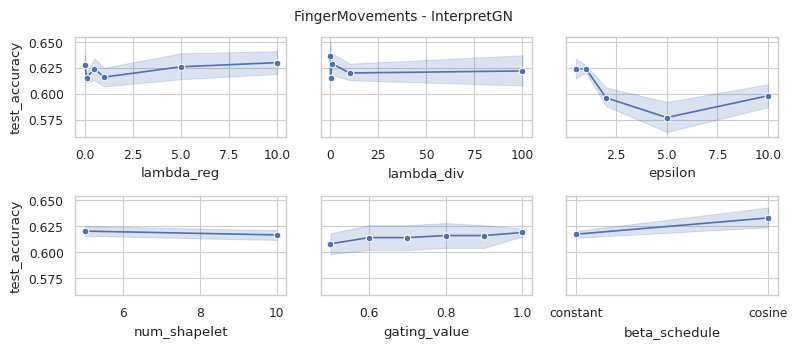

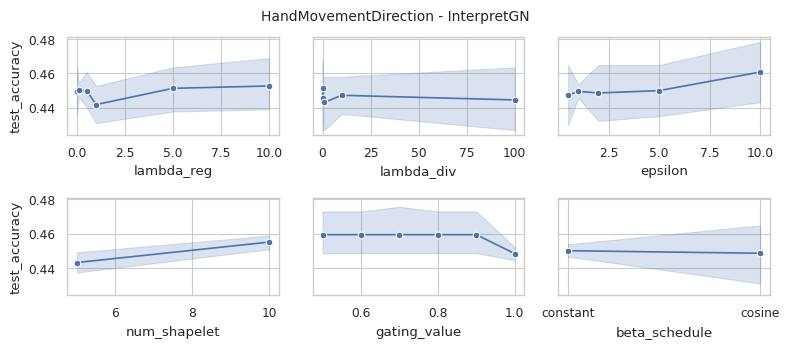

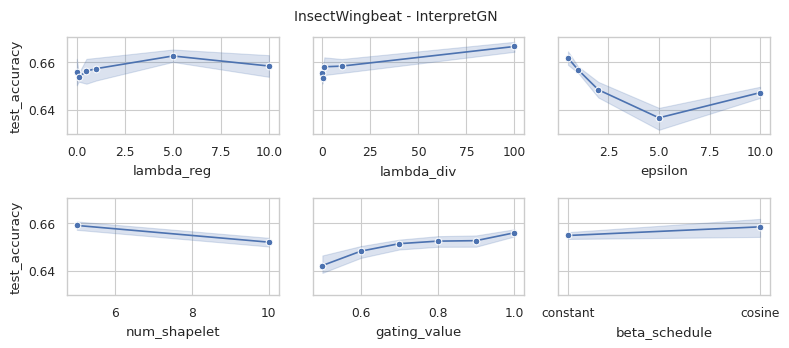

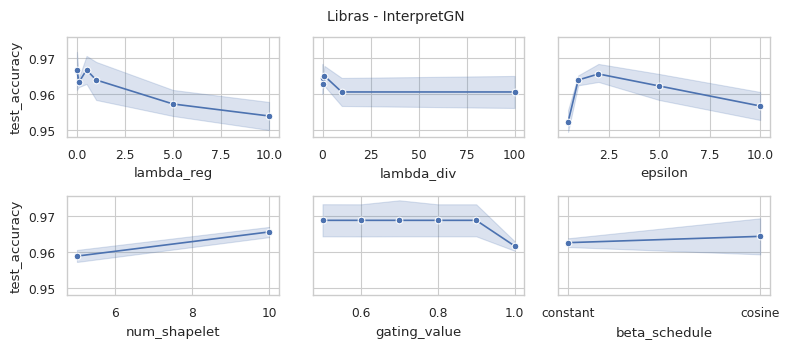

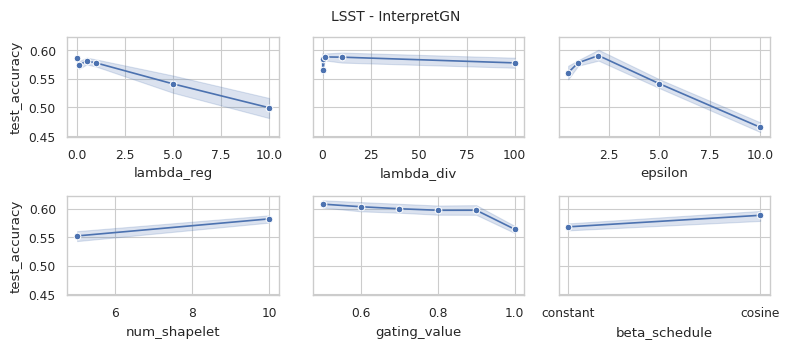

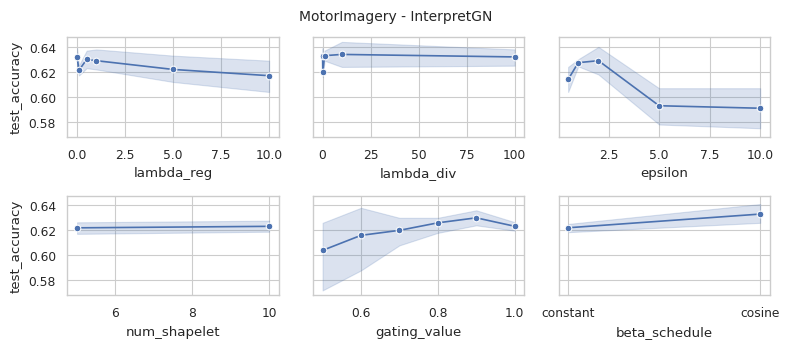

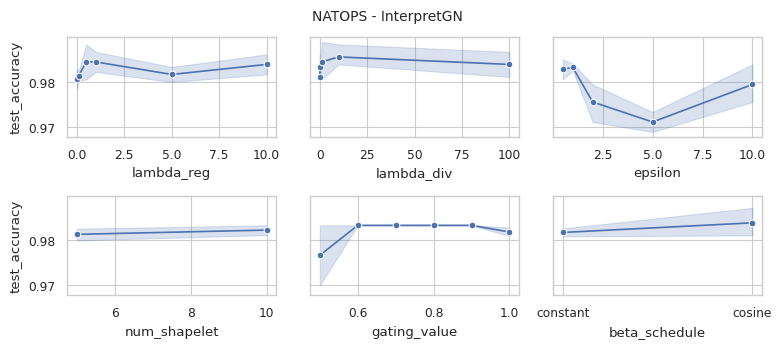

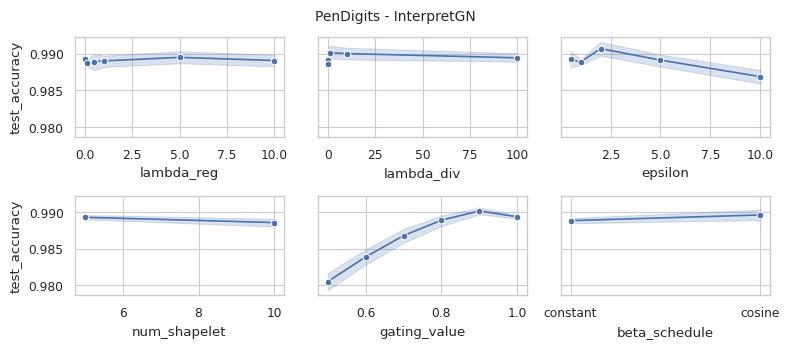

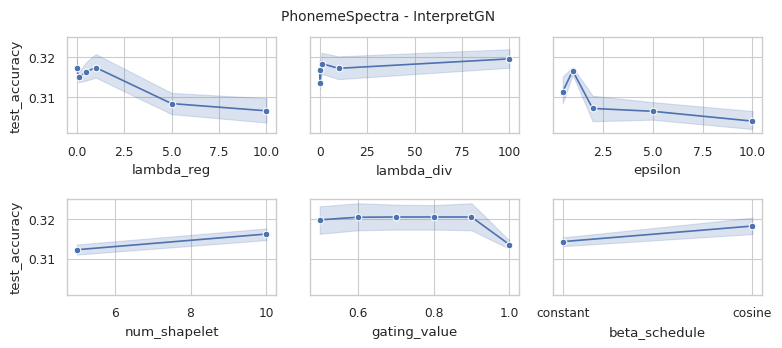

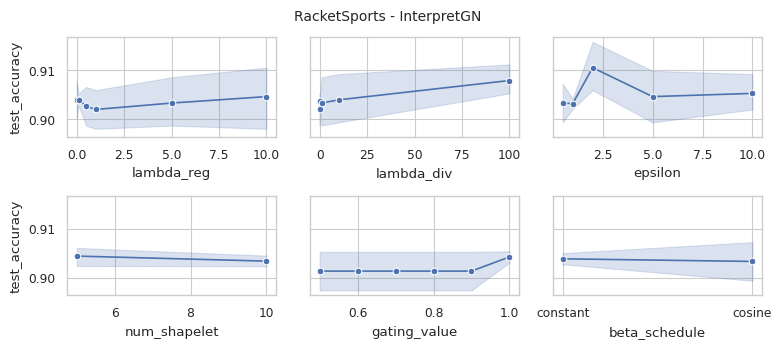

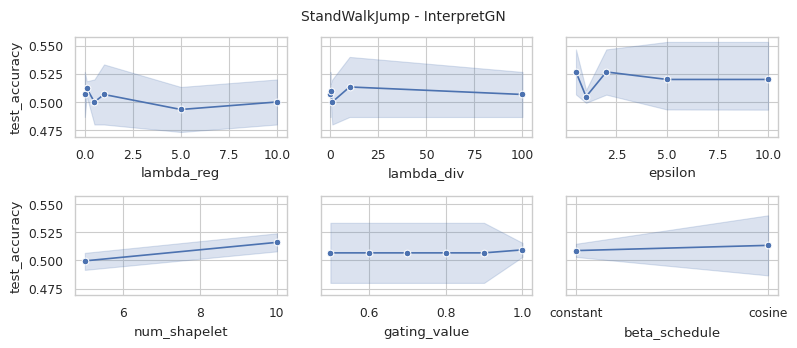

In [4]:
model = 'InterpretGN'
result_dict = dict()

for data_name in UEA_MTSC30:
    
    result_df = result_df_all[result_df_all['dataset'] == data_name]
    result_dict[data_name] = result_df.copy()

    cols = ['lambda_reg', 'lambda_div', 'epsilon',
            'num_shapelet', 'gating_value', 'beta_schedule', 
            # 'seed'
            ]
    num_cols, num_rows = 3, 2
    
    # # Boxplot
    # sns.set_theme(style="whitegrid")
    # sns.set_context("paper", font_scale=1)
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     sns.boxplot(x=col, y='test_accuracy', data=result_df, ax=axs[i%num_cols], legend=False)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)

    # Lineplot
    sns.set_theme(style="whitegrid")
    sns.set_context("paper", font_scale=1)
    fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    for i, col in enumerate(cols):
        if result_df[col].unique().size == 1: 
            sns.boxplot(x=col, y='test_accuracy', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False)
        else:
            sns.lineplot(x=col, y='test_accuracy', data=result_df, ax=axs[i//num_cols][i%num_cols], legend=False, style='model', markers=True)
    fig.suptitle(f'{data_name} - {model}', fontsize=10)
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)
    display(fig)
    # plt.savefig(f'./{model}/{data_name}.png', dpi=300, bbox_inches='tight')
    plt.close(fig)
    

    # # Lineplot where each line represents same hyperparameter combination except one
    # fig, axs = plt.subplots(ncols=num_cols, nrows=num_rows, figsize=(8, 3.5), sharey=True)
    # for i, col in enumerate(cols):
    #     col_rest = [c for c in cols if c != col]
    #     tmp_result = result_df.pivot_table(index=col_rest, columns=col, values='test_accuracy')
    #     tmp_result = pd.DataFrame(tmp_result.values, columns=tmp_result.columns)
    #     max_idx = tmp_result.mean(axis=1).idxmax()
    #     axs[i%num_cols].plot(tmp_result.T, marker='.', color='#111', alpha=0.2)
    #     axs[i%num_cols].plot(tmp_result.iloc[max_idx].T, marker='o', color='red', alpha=0.5)
    #     axs[i%num_cols].grid(False)
    #     axs[i%num_cols].set_xlabel(col)
    # fig.suptitle(f'{data_name} - {model}', fontsize=10)
    # plt.tight_layout()
    # plt.subplots_adjust(top=0.85)
    # display(fig)
    # plt.close(fig)
    
    
    

In [5]:
hyperparameter_combinations = \
    result_df_all[['lambda_reg', 'lambda_div', 'epsilon',
                   'num_shapelet', 'gating_value', 'beta_schedule']].drop_duplicates(
                   ).to_dict(orient='records')

acc_all_df = pd.DataFrame(index=UEA_MTSC30, 
                          columns=[str(hp_comb) for hp_comb in hyperparameter_combinations])
for data_name in UEA_MTSC30:
    acc_data_dict = dict()
    for hyperparameter_combination in hyperparameter_combinations:
        if result_dict.get(data_name) is None:
            continue

        tmp = result_dict[data_name]
        try:
            acc = tmp[
                (tmp['lambda_reg'] == hyperparameter_combination['lambda_reg']) &
                (tmp['lambda_div'] == hyperparameter_combination['lambda_div']) &
                (tmp['epsilon'] == hyperparameter_combination['epsilon']) &
                (tmp['num_shapelet'] == hyperparameter_combination['num_shapelet']) &
                (tmp['gating_value'] == hyperparameter_combination['gating_value']) &
                (tmp['beta_schedule'] == hyperparameter_combination['beta_schedule'])
                # (tmp['seed'] == hyperparameter_combination['seed'])
            ]['test_accuracy'].median()
        except:
            acc = None
            print(f'no acc for {data_name} with {hyperparameter_combination}')
        acc_data_dict[str(hyperparameter_combination)] = acc

    acc_all_df.loc[data_name] = pd.Series(acc_data_dict)



In [6]:
acc_all_df.loc[:,'max'] = acc_all_df.max(axis=1)
acc_all_df.loc['avg'] = acc_all_df.mean(axis=0)
acc_all_df.sort_values(by='avg', ascending=False, inplace=True, axis=1)
acc_all_df

,max,"{'lambda_reg': 0.1, 'lambda_div': 0.0, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.0, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 10.0, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'cosine'}","{'lambda_reg': 0.1, 'lambda_div': 100.0, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 0.9, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 0.8, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 1.0, 'epsilon': 1.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}",...,"{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 1.0, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 5.0, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 10.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 10.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 5.0, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 10.0, 'lambda_div': 0.1, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 0.5, 'num_shapelet': 10, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 5.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}","{'lambda_reg': 0.1, 'lambda_div': 0.1, 'epsilon': 0.5, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}"
EthanolConcentration,0.304183,0.304183,0.304183,0.296578,0.30038,0.30038,0.296578,0.296578,0.296578,0.296578,...,0.30038,0.30038,0.292776,0.304183,0.30038,0.296578,0.30038,0.304183,0.296578,0.30038
FaceDetection,0.664018,0.652384,0.661748,0.651532,0.664018,0.653235,0.656924,0.656924,0.657208,0.662032,...,0.649262,0.644438,0.628831,0.575766,0.577185,0.564983,0.626277,0.643587,0.571793,0.641317
Handwriting,0.618824,0.609412,0.618824,0.607059,0.615294,0.614118,0.612941,0.612941,0.612941,0.609412,...,0.605882,0.611765,0.607059,0.611765,0.611765,0.612941,0.607059,0.618824,0.605882,0.608235
Heartbeat,0.795122,0.795122,0.785366,0.77561,0.780488,0.785366,0.785366,0.785366,0.785366,0.780488,...,0.77561,0.770732,0.77561,0.795122,0.785366,0.790244,0.77561,0.780488,0.790244,0.780488
JapaneseVowels,0.991892,0.989189,0.989189,0.989189,0.989189,0.989189,0.989189,0.989189,0.989189,0.989189,...,0.989189,0.991892,0.991892,0.991892,0.989189,0.989189,0.991892,0.991892,0.986486,0.989189
PEMS-SF,0.884393,0.849711,0.884393,0.849711,0.855491,0.867052,0.867052,0.867052,0.867052,0.867052,...,0.861272,0.82659,0.861272,0.849711,0.849711,0.872832,0.83815,0.849711,0.867052,0.849711
SelfRegulationSCP1,0.924915,0.921502,0.918089,0.921502,0.918089,0.914676,0.914676,0.914676,0.914676,0.914676,...,0.921502,0.921502,0.918089,0.911263,0.901024,0.904437,0.90785,0.924915,0.894198,0.924915
SelfRegulationSCP2,0.577778,0.577778,0.572222,0.577778,0.577778,0.577778,0.577778,0.577778,0.577778,0.572222,...,0.577778,0.577778,0.572222,0.577778,0.577778,0.577778,0.572222,0.572222,0.577778,0.577778
SpokenA

In [7]:
pd.set_option("display.precision", 13)
acc_all_df.iloc[:,[0,1]]*100

,max,"{'lambda_reg': 0.1, 'lambda_div': 0.0, 'epsilon': 1.0, 'num_shapelet': 5, 'gating_value': 1.0, 'beta_schedule': 'constant'}"
EthanolConcentration,30.4182509505703,30.4182509505703
FaceDetection,66.4018161180477,65.2383654937571
Handwriting,61.8823529411765,60.9411764705882
Heartbeat,79.5121951219512,79.5121951219512
JapaneseVowels,99.1891891891892,98.9189189189189
PEMS-SF,88.4393063583815,84.9710982658959
SelfRegulationSCP1,92.4914675767918,92.1501706484642
SelfRegulationSCP2,57.7777777777778,57.7777777777778
SpokenArabicDigits,99.8180991359709,99.6816734879491
UWaveGestureLibrary,91.875,89.375
